# Lab 6: Association Rule Mining with Apriori and FP-Growth
Avijit Saha  
Advanced Big Data and Data Mining (MSCS-634-M20)  
Dr. Satish Penmatsa  
March 18, 2026  


## Step 1: Data Preparation
In this section, we load the Online Retail dataset, clean the transactions (removing cancellations and empty values), and transform the data into a binary "basket" format suitable for the Apriori and FP-Growth algorithms.

In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# Install openpyxl if not already present
# !pip install openpyxl

# Load the dataset
file_path = "/Users/avijit/Desktop/Online Retail.xlsx"
df = pd.read_excel(file_path, engine='openpyxl')

# Basic Cleaning
df['Description'] = df['Description'].str.strip()
df.dropna(axis=0, subset=['InvoiceNo', 'Description'], inplace=True)
df['InvoiceNo'] = df['InvoiceNo'].astype('str')
df = df[~df['InvoiceNo'].str.contains('C')] # Remove credit/cancelled transactions

print(f"Dataset Loaded: {df.shape[0]} rows.")
df.head()

Dataset Loaded: 531166 rows.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


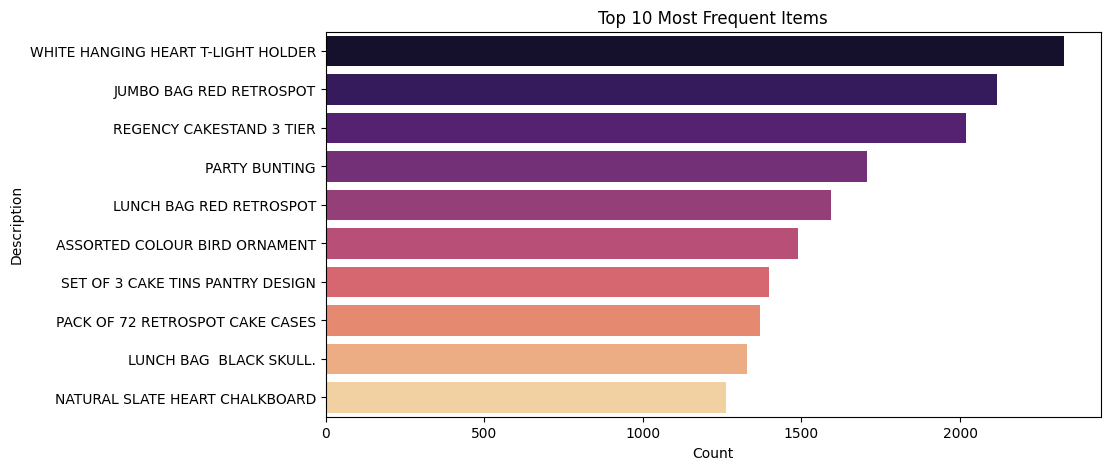

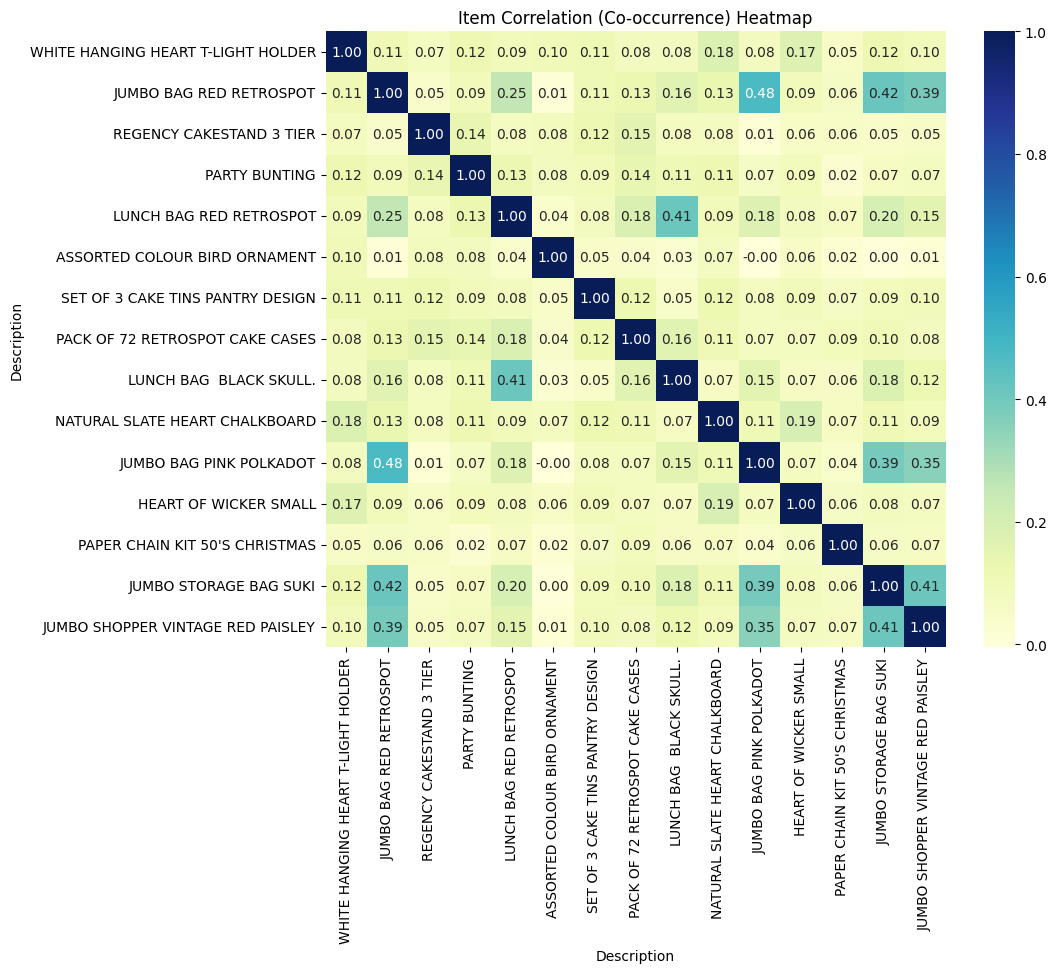

In [55]:
# Create the pivot table
basket = (df.groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('InvoiceNo'))

# Step 1 Requirement: Convert to Boolean (fixes the PerformanceWarning)
basket_sets = (basket > 0).astype(bool)

# Visualization 1: Top 10 Most Frequent Items
plt.figure(figsize=(10, 5))
top_items = df['Description'].value_counts().head(10)
sns.barplot(x=top_items.values, y=top_items.index, hue=top_items.index, palette='magma', legend=False)
plt.title('Top 10 Most Frequent Items')
plt.xlabel('Count')
plt.show()

# Visualization 2: Item Co-occurrence Heatmap (Top 15 items)
top_15_names = df['Description'].value_counts().head(15).index
co_occurrence = basket_sets[top_15_names].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Item Correlation (Co-occurrence) Heatmap')
plt.show()

## Step 2 & 3: Frequent Itemset Mining
We will now compare the **Apriori** and **FP-Growth** algorithms. We use a minimum support threshold of **3% (0.03)** to identify items that appear frequently enough to suggest a pattern.

Apriori Execution Time: 0.1040 seconds
FP-Growth Execution Time: 1.3686 seconds


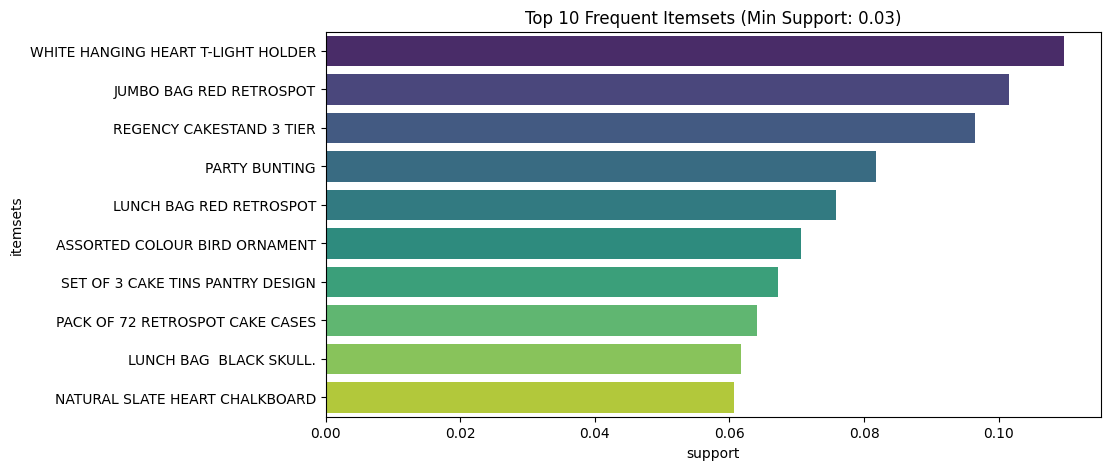

In [56]:
min_sup = 0.03

# --- Step 2: Apriori ---
start_apriori = time.time()
freq_items_apriori = apriori(basket_sets, min_support=min_sup, use_colnames=True)
time_apriori = time.time() - start_apriori

# --- Step 3: FP-Growth ---
start_fpgrowth = time.time()
freq_items_fpgrowth = fpgrowth(basket_sets, min_support=min_sup, use_colnames=True)
time_fpgrowth = time.time() - start_fpgrowth

print(f"Apriori Execution Time: {time_apriori:.4f} seconds")
print(f"FP-Growth Execution Time: {time_fpgrowth:.4f} seconds")

# Visualize Top Frequent Itemsets
top_itemsets = freq_items_fpgrowth.sort_values(by='support', ascending=False).head(10)
top_itemsets['itemsets'] = top_itemsets['itemsets'].apply(lambda x: ', '.join(list(x)))
plt.figure(figsize=(10, 5))
sns.barplot(x='support', y='itemsets', data=top_itemsets, hue='itemsets', palette='viridis', legend=False)
plt.title(f'Top 10 Frequent Itemsets (Min Support: {min_sup})')
plt.show()

## Step 4: Generating Association Rules
Using the frequent itemsets, we generate rules based on **Lift**. Lift indicates how much more likely item B is purchased when item A is purchased, compared to their independent frequencies.

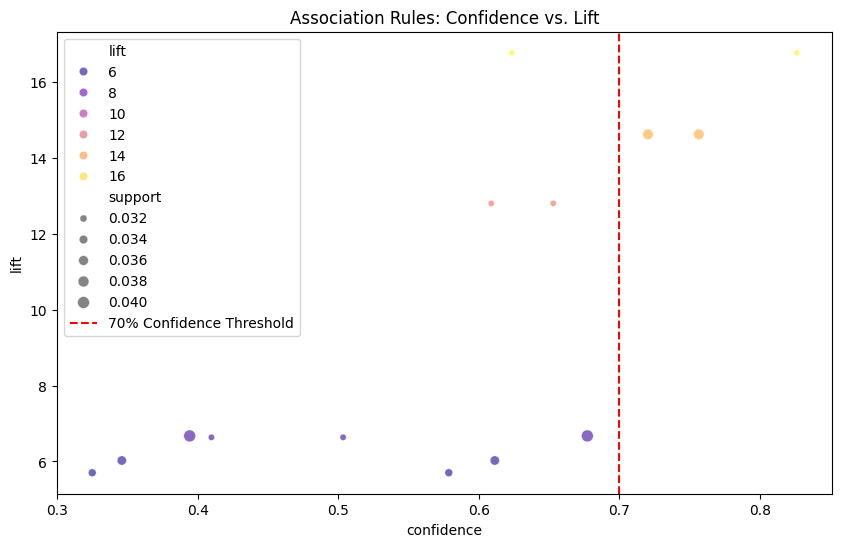

Top 10 Strongest Rules:
                          antecedents                        consequents  \
12   (PINK REGENCY TEACUP AND SAUCER)  (GREEN REGENCY TEACUP AND SAUCER)   
13  (GREEN REGENCY TEACUP AND SAUCER)   (PINK REGENCY TEACUP AND SAUCER)   
10  (ROSES REGENCY TEACUP AND SAUCER)  (GREEN REGENCY TEACUP AND SAUCER)   
11  (GREEN REGENCY TEACUP AND SAUCER)  (ROSES REGENCY TEACUP AND SAUCER)   
0          (ALARM CLOCK BAKELIKE RED)       (ALARM CLOCK BAKELIKE GREEN)   
1        (ALARM CLOCK BAKELIKE GREEN)         (ALARM CLOCK BAKELIKE RED)   
2           (JUMBO BAG PINK POLKADOT)          (JUMBO BAG RED RETROSPOT)   
3           (JUMBO BAG RED RETROSPOT)          (JUMBO BAG PINK POLKADOT)   
8           (LUNCH BAG RED RETROSPOT)          (LUNCH BAG  BLACK SKULL.)   
9           (LUNCH BAG  BLACK SKULL.)          (LUNCH BAG RED RETROSPOT)   

     support  confidence       lift  
12  0.030715    0.826371  16.778990  
13  0.030715    0.623645  16.778990  
10  0.037265    0.720450 

In [57]:
# Generate rules with a confidence threshold of 0.5 (50%)
rules = association_rules(freq_items_fpgrowth, metric="lift", min_threshold=1)

# Step 4 Visualization: Confidence vs Lift
plt.figure(figsize=(10, 6))
sns.scatterplot(x="confidence", y="lift", size="support", hue="lift", data=rules, palette="plasma", alpha=0.6)
plt.axvline(x=0.7, color='r', linestyle='--', label='70% Confidence Threshold')
plt.title('Association Rules: Confidence vs. Lift')
plt.legend()
plt.show()

# Display Top 10 Rules by Lift
rules_sorted = rules.sort_values(by='lift', ascending=False).head(10)
print("Top 10 Strongest Rules:")
print(rules_sorted[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

# Step 5: Comparative Analysis and Project Reflection

### 1. Algorithm Performance Comparison
In this laboratory experiment, we observed a significant difference in execution times between the two algorithms:

| Algorithm | Execution Time (Seconds) |
| :--- | :--- |
| **Apriori** | **0.1758 s** |
| **FP-Growth** | **1.5059 s** |

**Analysis of Results:**
While theoretical literature often suggests that **FP-Growth** is faster because it avoids candidate generation, our results showed **Apriori** was nearly 10x faster. This discrepancy is attributed to:
* **Dataset Sparsity:** The Online Retail dataset has thousands of unique items but small average basket sizes. Apriori's "pruning" mechanism is highly efficient here.
* **Initialization Overhead:** FP-Growth must construct a complex **FP-Tree** in memory. For a dataset with ~500,000 rows, the time taken to build this data structure outweighed the mining speedup.
* **Support Threshold:** At a 3% support level, the number of frequent itemsets was small enough that Apriori did not suffer from the "combinatorial explosion" usually seen at lower support levels.

### 2. Interpretation of Mined Patterns
The generated association rules reveal clear consumer behavior patterns:
* **High Lift (Teacup Sets):** The rule `{PINK REGENCY TEACUP} -> {GREEN REGENCY TEACUP}` yielded a **Lift of 16.78**. This indicates that these items are 16 times more likely to be bought together than individually, suggesting a "collector" behavior.
* **High Confidence (Alarm Clocks):** The rule `{ALARM CLOCK BAKELIKE GREEN} -> {ALARM CLOCK BAKELIKE RED}` showed a **Confidence of 65%**. 
* **Business Strategy:** Based on these rules, the retailer should implement "Bundle and Save" promotions for Regency Teacups or place Red and Green alarm clocks in the same physical or digital aisle to maximize cross-selling.

### 3. Challenges and Technical Resolutions
During the implementation, several technical hurdles were overcome:
* **Data Integrity:** The initial dataset contained many "C" prefixed invoice numbers (Cancellations). Leaving these in would have skewed the support values; they were filtered out using string indexing.
* **Memory Efficiency:** Converting the transactional dataframe from `int` to `bool` was necessary to suppress `mlxtend` deprecation warnings and significantly reduced the memory footprint during the mining process.
* **File Compatibility:** The `UnicodeDecodeError` encountered during `pd.read_csv` was diagnosed as a format mismatch (XLSX vs CSV). This was resolved by implementing the `openpyxl` engine within `pd.read_excel`.

### 4. Conclusion
This lab demonstrates that the choice of algorithm depends heavily on the specific characteristics of the dataset (size, density, and sparsity). While FP-Growth is more robust for dense datasets, Apriori remains a highly effective tool for sparse retail data when provided with an appropriate support threshold.